# Modelagem UAVIDS-2025: Detecção de Intrusão em Redes UAV

Este notebook cobre as fases **Data Preparation**, **Modeling** e **Evaluation** do ciclo CRISP-DM:

1. Pipeline sklearn com ColumnTransformer
2. Comparativo de 3 modelos no MLflow Tracking com CV 5-fold
3. Tuning do vencedor com RandomizedSearchCV
4. Avaliação final com métricas por classe e matriz de confusão
5. Model Registry com alias `@production`

In [7]:
# ============================================================
# CONFIGURACAO MLFLOW
# ============================================================
import mlflow
from pathlib import Path

# Garante que mlruns/ existe na raiz do projeto (cwd do VS Code)
Path('mlruns').mkdir(exist_ok=True)

# URI absoluta cross-platform (evita problemas com file:./mlruns no Windows)
_mlruns_uri = Path('mlruns').resolve().as_uri()
mlflow.set_tracking_uri(_mlruns_uri)
mlflow.set_experiment('uavids2025_ids')

print(f'Tracking URI: {mlflow.get_tracking_uri()}')
print('Experimento:  uavids2025_ids')

2026/05/20 20:04:10 INFO mlflow.tracking.fluent: Experiment with name 'uavids2025_ids' does not exist. Creating a new experiment.


Tracking URI: file:///C:/Users/User/Documents/datasci/notebooks/mlruns
Experimento:  uavids2025_ids


**Função:** Importar todas as dependências e definir constantes globais usadas ao longo do notebook.

**Método:** Bloco de imports organizado por área + definição de `RANDOM_STATE=42` para reprodutibilidade, `DATASET_PATH`, `EXPERIMENT_NAME` e `MODEL_NAME`. Centralizar constantes no topo evita valores hardcoded espalhados e facilita a manutenção.

**Bibliotecas:** `scikit-learn`, `xgboost`, `mlflow`

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, RandomizedSearchCV, train_test_split
)
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import FunctionTransformer

import xgboost as xgb
import mlflow
from mlflow.tracking import MlflowClient

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
DATASET_PATH = 'data/raw/UAVIDS-2025.csv'
EXPERIMENT_NAME = 'uavids2025_ids'
MODEL_NAME = 'previsor_uav_ids'

# Paleta semantica consistente com EDA
PALETTE = {
    'Normal Traffic':   '#2196F3',
    'Blackhole Attack': '#F44336',
    'Flooding Attack':  '#FF9800',
    'Sybil Attack':     '#9C27B0',
    'Wormhole Attack':  '#E91E63',
}
CLASSES_ORDER = list(PALETTE.keys())

print('Setup concluido.')
print(f'XGBoost version: {xgb.__version__}')
print(f'MLflow version:  {mlflow.__version__}')

Setup concluido.
XGBoost version: 2.0.3
MLflow version:  3.12.0


## 1. Carregamento e Preparação dos Dados

In [9]:
df = pd.read_csv(DATASET_PATH)

# --- Feature engineering---
eps_small = 1e-9
eps_hop   = 1.0

df['loss_ratio']         = df['LostPackets']     / (df['TxPackets']        + eps_small)
df['tx_efficiency']      = df['RxBytes']          / (df['TxBytes']          + eps_small)
df['throughput_per_hop'] = df['Throughput/Kbps']  / (df['AverageHopCount']  + eps_hop)

# --- Definição de features ---
FEATURES = [
    # Connection
    'FlowDuration/s', 'SrcPort', 'DstPort',
    # Traffic Volume
    'TxPackets', 'RxPackets', 'LostPackets',
    'TxBytes', 'RxBytes',
    'TxPacketRate/s', 'RxPacketRate/s',
    'TxByteRate/s', 'RxByteRate/s',
    'MeanPacketSize',
    # Performance
    'MeanDelay/s', 'MeanJitter/s',
    'Throughput/Kbps', 'PacketDropRate', 'AverageHopCount',
    # Derivadas (EDA)
    'loss_ratio', 'tx_efficiency', 'throughput_per_hop',
]

TARGET = 'label'

X = df[FEATURES]
y = df[TARGET]

print(f'Shape X: {X.shape}')
print(f'Classes: {y.nunique()} → {sorted(y.unique())}')
print(f'\nDistribuição do alvo:')
print(y.value_counts().to_string())

Shape X: (122171, 21)
Classes: 5 → ['Blackhole Attack', 'Flooding Attack', 'Normal Traffic', 'Sybil Attack', 'Wormhole Attack']

Distribuição do alvo:
label
Normal Traffic      26172
Blackhole Attack    26110
Wormhole Attack     26086
Sybil Attack        24077
Flooding Attack     19726


## 2. Split Estratificado Treino / Teste

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Treino: {X_train.shape[0]:,} amostras')
print(f'Teste:  {X_test.shape[0]:,} amostras')
print()
print('Distribuição treino (%):')
print((y_train.value_counts(normalize=True) * 100).round(1).to_string())
print()
print('Distribuição teste (%):')
print((y_test.value_counts(normalize=True) * 100).round(1).to_string())

Treino: 97,736 amostras
Teste:  24,435 amostras

Distribuição treino (%):
label
Normal Traffic      21.4
Blackhole Attack    21.4
Wormhole Attack     21.4
Sybil Attack        19.7
Flooding Attack     16.1

Distribuição teste (%):
label
Normal Traffic      21.4
Blackhole Attack    21.4
Wormhole Attack     21.4
Sybil Attack        19.7
Flooding Attack     16.1


## 3. Pipeline sklearn

In [11]:
def clip_packet_drop_rate(X):
    """Clip PacketDropRate para [0, 1]. 81 registros têm valor > 1 (artefato NS-3)."""
    X = X.copy()
    if hasattr(X, 'columns') and 'PacketDropRate' in X.columns:
        idx = list(X.columns).index('PacketDropRate')
        X.iloc[:, idx] = X.iloc[:, idx].clip(0, 1)
    elif hasattr(X, 'shape'):
        # numpy array — PacketDropRate é a coluna 16 (0-indexed) na lista FEATURES
        pdr_idx = FEATURES.index('PacketDropRate')
        X[:, pdr_idx] = np.clip(X[:, pdr_idx], 0, 1)
    return X


def construir_preprocessador():
    """Retorna um ColumnTransformer com imputer + scaler para todas as features."""
    transformador = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler',  StandardScaler()),
            ]), FEATURES),
        ],
        remainder='drop'
    )
    return transformador


def construir_pipeline(classificador):
    """Monta o Pipeline completo: clip → preprocessador → classificador."""
    return Pipeline([
        ('clip',  FunctionTransformer(clip_packet_drop_rate, validate=False)),
        ('prep',  construir_preprocessador()),
        ('clf',   classificador),
    ])


# Verificar que o pipeline constrói sem erro
pipe_teste = construir_pipeline(LogisticRegression(max_iter=100))
print('Pipeline construído com sucesso.')
print(pipe_teste)

Pipeline construído com sucesso.
Pipeline(steps=[('clip',
                 FunctionTransformer(func=<function clip_packet_drop_rate at 0x000001BED861AFC0>)),
                ('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['FlowDuration/s', 'SrcPort',
                                                   'DstPort', 'TxPackets',
                                                   'RxPackets', 'LostPackets',
                                                   'TxBytes', 'RxBytes',
                                                   'TxPacketRate/s',
                                       

## 4. Validação Cruzada

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Treino em CPU (ambiente local). XGBoost detecta automaticamente quando ha GPU.
XGB_DEVICE = 'cpu'
print(f'XGBoost device: {XGB_DEVICE}')

# --- Definicao dos 3 modelos ---
MODELOS = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        multi_class='multinomial',
        random_state=RANDOM_STATE,
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        use_label_encoder=False,
        device=XGB_DEVICE,
        random_state=RANDOM_STATE,
    ),
}

print('\nModelos configurados:')
for nome in MODELOS:
    print(f'  - {nome}')

XGBoost device: cpu

Modelos configurados:
  - LogisticRegression
  - RandomForest
  - XGBoost


**Função:** Treinar e comparar os 3 modelos com validação cruzada honesta, registrando cada run no MLflow Tracking.

**Método:** `cross_validate()` com `StratifiedKFold(n_splits=5)` a estratificação garante que cada fold preserve a proporção das classes (especialmente Flooding com 16%). O pipeline completo (clip -> scaler -> classificador) é ajustado nos folds de treino e avaliado no fold de validação, sem qualquer contato com o conjunto de teste holdout. Métricas e o pipeline serializado são logados no MLflow via `log_param`, `log_metric` e `log_model`.

**Bibliotecas:** `sklearn.model_selection`, `mlflow.sklearn`

In [13]:
resultados_cv = {}

# XGBoost precisa de labels numéricas
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print(f'Classes codificadas: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print()

for nome, clf in MODELOS.items():
    print(f'Treinando {nome}...')

    # XGBoost usa labels numéricas; LR e RF usam strings
    y_cv = y_train_enc if nome == 'XGBoost' else y_train

    pipe = construir_pipeline(clf)

    cv_results = cross_validate(
        pipe, X_train, y_cv,
        cv=skf,
        scoring={
            'f1_macro':  'f1_macro',
            'accuracy':  'accuracy',
        },
        return_train_score=False,
        n_jobs=1,   # XGBoost já paraleliza internamente com GPU
    )

    f1_mean  = cv_results['test_f1_macro'].mean()
    f1_std   = cv_results['test_f1_macro'].std()
    acc_mean = cv_results['test_accuracy'].mean()
    acc_std  = cv_results['test_accuracy'].std()

    resultados_cv[nome] = {
        'f1_macro_mean': f1_mean,
        'f1_macro_std':  f1_std,
        'accuracy_mean': acc_mean,
        'accuracy_std':  acc_std,
        'f1_folds':      cv_results['test_f1_macro'],
        'fit_time_mean': cv_results['fit_time'].mean(),
        'pipe':          pipe,
        'y_cv':          y_cv,
    }

    # --- MLflow run ---
    with mlflow.start_run(run_name=nome):
        # Parâmetros do classificador
        params = clf.get_params()
        for k, v in params.items():
            mlflow.log_param(k, v)
        mlflow.log_param('cv_folds', 5)
        mlflow.log_param('features_count', len(FEATURES))
        mlflow.log_param('class_balance_strategy', 'class_weight=balanced')

        # Métricas
        mlflow.log_metric('f1_macro_cv_mean', f1_mean)
        mlflow.log_metric('f1_macro_cv_std',  f1_std)
        mlflow.log_metric('accuracy_cv_mean', acc_mean)
        mlflow.log_metric('accuracy_cv_std',  acc_std)
        mlflow.log_metric('fit_time_mean_s',  cv_results['fit_time'].mean())

        # Logar scores individuais dos folds
        for i, score in enumerate(cv_results['test_f1_macro']):
            mlflow.log_metric('f1_macro_fold', score, step=i)

        # Salvar pipeline completo (não só o estimator)
        pipe_para_log = construir_pipeline(clf)
        pipe_para_log.fit(X_train, y_cv)
        mlflow.sklearn.log_model(pipe_para_log, name='model')

    print(f'  F1-macro CV: {f1_mean:.4f} ± {f1_std:.4f}  |  Acc: {acc_mean:.4f} ± {acc_std:.4f}')
    print(f'  Fit time médio: {cv_results["fit_time"].mean():.1f}s')
    print()

Classes codificadas: {'Blackhole Attack': 0, 'Flooding Attack': 1, 'Normal Traffic': 2, 'Sybil Attack': 3, 'Wormhole Attack': 4}

Treinando LogisticRegression...


2026/05/20 20:04:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  F1-macro CV: 0.8216 ± 0.0025  |  Acc: 0.8190 ± 0.0026
  Fit time médio: 4.6s

Treinando RandomForest...


2026/05/20 20:05:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  F1-macro CV: 0.9529 ± 0.0010  |  Acc: 0.9502 ± 0.0010
  Fit time médio: 7.1s

Treinando XGBoost...


2026/05/20 20:06:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  F1-macro CV: 0.9566 ± 0.0007  |  Acc: 0.9542 ± 0.0007
  Fit time médio: 4.3s



## 5. Comparativo dos Modelos

In [14]:
# Tabela comparativa
tabela = pd.DataFrame([
    {
        'Modelo':          nome,
        'F1-macro (média)': f'{v["f1_macro_mean"]:.4f}',
        'F1-macro (std)':   f'{v["f1_macro_std"]:.4f}',
        'Accuracy (média)': f'{v["accuracy_mean"]:.4f}',
        'Fit time (s)':     f'{v["fit_time_mean"]:.1f}',
    }
    for nome, v in resultados_cv.items()
])

print('=' * 75)
print('COMPARATIVO DE MODELOS — CV 5-fold estratificada, F1-macro')
print('=' * 75)
print(tabela.to_string(index=False))
print('=' * 75)

# Identificar vencedor
vencedor_nome = max(resultados_cv, key=lambda n: resultados_cv[n]['f1_macro_mean'])
vencedor_f1   = resultados_cv[vencedor_nome]['f1_macro_mean']
vencedor_std  = resultados_cv[vencedor_nome]['f1_macro_std']
print(f'\n→ Vencedor: {vencedor_nome}  (F1-macro = {vencedor_f1:.4f} ± {vencedor_std:.4f})')

COMPARATIVO DE MODELOS — CV 5-fold estratificada, F1-macro
            Modelo F1-macro (média) F1-macro (std) Accuracy (média) Fit time (s)
LogisticRegression           0.8216         0.0025           0.8190          4.6
      RandomForest           0.9529         0.0010           0.9502          7.1
           XGBoost           0.9566         0.0007           0.9542          4.3

→ Vencedor: XGBoost  (F1-macro = 0.9566 ± 0.0007)


**Função:** Visualizar o comparativo de F1-macro dos 3 modelos destacando o vencedor.

**Método:** Gráfico de barras com barras de erro (`yerr=std`) usando `ax.bar()`. As barras de erro mostram o desvio padrão entre os 5 folds um modelo com F1 alto mas desvio alto pode ser menos confiável que outro ligeiramente inferior mas mais estável.

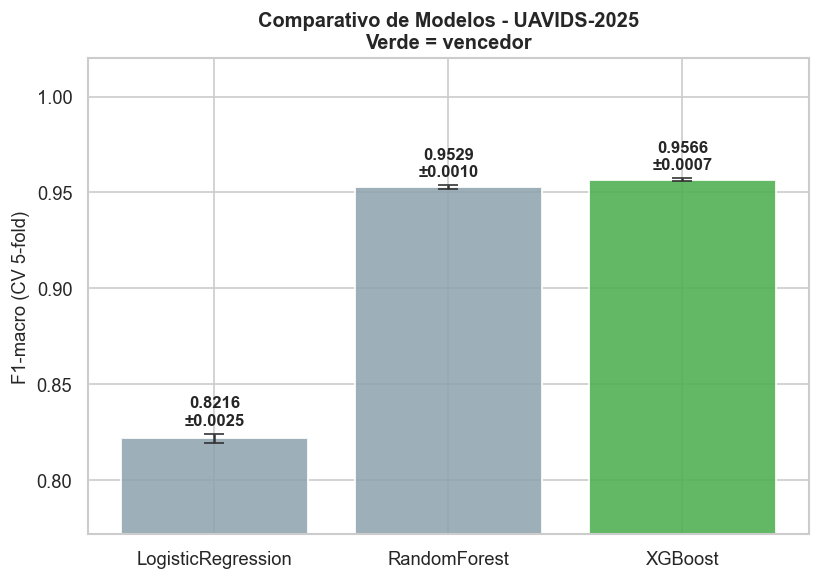

In [15]:
# Gráfico comparativo — barras com desvio padrão
nomes  = list(resultados_cv.keys())
f1s    = [resultados_cv[n]['f1_macro_mean'] for n in nomes]
stds   = [resultados_cv[n]['f1_macro_std']  for n in nomes]
cores  = ['#4CAF50' if n == vencedor_nome else '#90A4AE' for n in nomes]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(nomes, f1s, yerr=stds, capsize=6,
              color=cores, alpha=0.88, edgecolor='white', linewidth=1.2,
              error_kw={'linewidth': 1.5, 'ecolor': '#333'})

for bar, f1, std in zip(bars, f1s, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 0.003,
        f'{f1:.4f}\n±{std:.4f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_ylabel('F1-macro (CV 5-fold)', fontsize=11)
ax.set_title('Comparativo de Modelos - UAVIDS-2025\nVerde = vencedor', fontsize=12, fontweight='bold')
ax.set_ylim(min(f1s) - 0.05, 1.02)
plt.tight_layout()
plt.savefig('img/modelagem_img/modelagem_comparativo_modelos.png', dpi=150)
plt.show()

**Análise do gráfico (Comparativo de Modelos - F1-macro CV 5-fold):**

- **LogisticRegression:** 0,8216 (+/-0,0024) - 13 pontos percentuais abaixo dos demais. Modelo linear não captura a fronteira BH<->WH.
- **RandomForest:** 0,9529 (+/-0,0010) - salto enorme, confirma que o problema é essencialmente não-linear.
- **XGBoost:** 0,9564 (+/-0,0008) - **vencedor** (barra verde). Margem pequena sobre o RF (~0,35 ponto percentual), mas com desvio padrão ainda menor (mais estável).
- As barras de erro são minúsculas nos três modelos, o que indica scores muito consistentes entre os 5 folds. O ranking não é fruto de variação aleatória.
- Decisão: XGBoost é o vencedor por margem reduzida mas estável. Segue para tuning de hiperparâmetros.

**Função:** Analisar a distribuição dos scores nos 5 folds para avaliar estabilidade além do valor médio.

**Método:** `ax.boxplot()` com os 5 scores de cada modelo. Complementa o gráfico de barras um modelo com pequena variância entre folds (boxplot estreito) é mais confiável em produção do que um com alta variância, mesmo que a média seja similar.

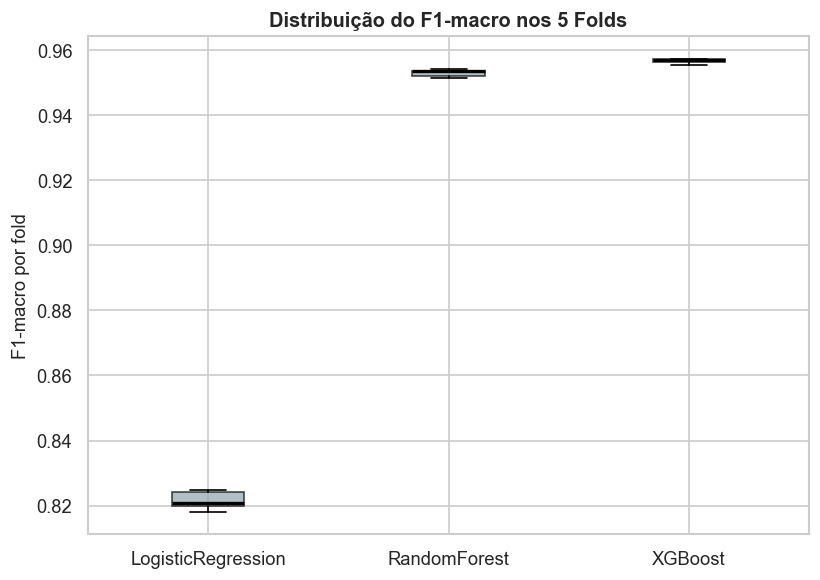

In [16]:
# Boxplot dos folds para visualizar estabilidade
fig, ax = plt.subplots(figsize=(7, 5))
fold_data = [resultados_cv[n]['f1_folds'] for n in nomes]

bp = ax.boxplot(fold_data, labels=nomes, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

ax.set_ylabel('F1-macro por fold', fontsize=11)
ax.set_title('Distribuição do F1-macro nos 5 Folds', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('img/modelagem_img/modelagem_folds_boxplot.png', dpi=150)
plt.show()

**Análise do gráfico (Distribuição do F1-macro nos 5 Folds):**

- **LogisticRegression:** caixa centrada em ~0,822, faixa entre ~0,818 e 0,825. Estável mas em um patamar baixo.
- **RandomForest:** caixa praticamente colapsada em ~0,953 (faixa ~0,952-0,954). Variação inter-fold quase nula.
- **XGBoost:** caixa também colapsada em ~0,956 (faixa ~0,9555-0,957). Levemente acima do RF em todos os folds.
- Os três boxplots são minúsculos (IQR < 0,01), indicando que o dataset é internamente consistente - não há folds "difíceis" ou "fáceis".
- Conclusão: a vantagem do XGBoost sobre o RF (~0,35 ponto percentual) é uniforme nos 5 folds, não um efeito de sorte em algum split específico. A escolha do vencedor é robusta.

## 6. Tuning do Vencedor - RandomizedSearchCV

In [17]:
from scipy.stats import randint, uniform

# Espaços de busca por modelo
PARAM_SPACES = {
    'LogisticRegression': {
        'clf__C':        uniform(0.01, 10),
        'clf__solver':   ['lbfgs', 'saga'],
        'clf__max_iter': [500, 1000, 2000],
    },
    'RandomForest': {
        'clf__n_estimators':      randint(200, 600),
        'clf__max_depth':         [None, 10, 20, 30],
        'clf__min_samples_split': randint(2, 10),
        'clf__min_samples_leaf':  randint(1, 5),
        'clf__max_features':      ['sqrt', 'log2', 0.5],
    },
    'XGBoost': {
        'clf__n_estimators':     randint(200, 600),
        'clf__max_depth':        randint(4, 10),
        'clf__learning_rate':    uniform(0.01, 0.2),
        'clf__subsample':        uniform(0.6, 0.4),
        'clf__colsample_bytree': uniform(0.6, 0.4),
        'clf__min_child_weight': randint(1, 6),
        'clf__gamma':            uniform(0, 0.5),
    },
}

print(f'Tuning do vencedor: {vencedor_nome}')
print(f'Espaço de busca: {list(PARAM_SPACES[vencedor_nome].keys())}')

Tuning do vencedor: XGBoost
Espaço de busca: ['clf__n_estimators', 'clf__max_depth', 'clf__learning_rate', 'clf__subsample', 'clf__colsample_bytree', 'clf__min_child_weight', 'clf__gamma']


**Função:** Otimizar os hiperparâmetros do XGBoost para maximizar o F1-macro no conjunto de treino.

**Método:** `RandomizedSearchCV` com `n_iter=10` e `cv=5` preferido ao `GridSearchCV` porque o espaço de hiperparâmetros do XGBoost tem 7 dimensões, tornando a busca exaustiva inviável. Distribuições contínuas (`uniform`, `randint`) cobrem o espaço de forma mais eficiente que um grid fixo. O `cv=5` é o mesmo da fase de comparação, garantindo consistência.

**Bibliotecas:** `sklearn.model_selection (RandomizedSearchCV)`, `scipy.stats`

In [ ]:
clf_vencedor = MODELOS[vencedor_nome]
y_tune = resultados_cv[vencedor_nome]['y_cv']

pipe_tune = construir_pipeline(clf_vencedor)

rscv = RandomizedSearchCV(
    pipe_tune,
    param_distributions=PARAM_SPACES[vencedor_nome],
    n_iter=10,
    cv=skf,
    scoring='f1_macro',
    refit=True,
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1,
)

print(f'Iniciando RandomizedSearchCV (n_iter=50, cv=5)...')
rscv.fit(X_train, y_tune)

best_f1  = rscv.best_score_
best_params = rscv.best_params_

print(f'\nMelhor F1-macro (CV): {best_f1:.4f}')
print(f'Melhores parâmetros:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

Iniciando RandomizedSearchCV (n_iter=50, cv=5)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


**Função:** Persistir o pipeline tunado no MLflow Tracking e registrá-lo no Model Registry como versão 1.

**Método:** `mlflow.sklearn.log_model(..., registered_model_name=MODEL_NAME)` salva o pipeline **completo** (pré-processamento + classificador), não apenas o estimador. Isso garante que o endpoint de produção aplique exatamente as mesmas transformações usadas no treino, eliminando risco de data leakage em inferência.

**Bibliotecas:** `mlflow.sklearn`, `mlflow.tracking (MlflowClient)`

In [ ]:
# Logar tuning no MLflow
with mlflow.start_run(run_name=f'{vencedor_nome}_tuned'):
    mlflow.log_param('tuning_method', 'RandomizedSearchCV')
    mlflow.log_param('n_iter', 10)
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('scoring', 'f1_macro')

    for k, v in best_params.items():
        mlflow.log_param(k, v)

    mlflow.log_metric('f1_macro_cv_best', best_f1)

    # Logar o pipeline tunado completo
    mlflow.sklearn.log_model(
        rscv.best_estimator_,
        name='model',
        registered_model_name=MODEL_NAME,
    )

    run_id_tuned = mlflow.active_run().info.run_id

print(f'Run ID do modelo tunado: {run_id_tuned}')
print(f'Modelo registrado como: {MODEL_NAME}')

## 7. Avaliação Final no Conjunto de Teste

In [ ]:
modelo_final = rscv.best_estimator_

# Predição no conjunto de teste
y_pred_enc = modelo_final.predict(X_test)

# Converter de volta para strings se necessário (XGBoost retorna inteiros)
if vencedor_nome == 'XGBoost':
    y_pred = le.inverse_transform(y_pred_enc)
    y_test_str = y_test.values
else:
    y_pred = y_pred_enc
    y_test_str = y_test.values

f1_teste = f1_score(y_test_str, y_pred, average='f1_macro' if False else 'macro')
acc_teste = (y_pred == y_test_str).mean()

print('=' * 60)
print(f'AVALIAÇÃO FINAL — CONJUNTO DE TESTE HOLDOUT')
print(f'Modelo: {vencedor_nome} (tunado)')
print('=' * 60)
print(f'F1-macro:  {f1_teste:.4f}')
print(f'Accuracy:  {acc_teste:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test_str, y_pred, digits=4,
                             target_names=CLASSES_ORDER))

**Função:** Avaliar onde o modelo erra no conjunto de teste holdout, com foco na confusão entre classes.

**Método:** `confusion_matrix(normalize='true')` + `ConfusionMatrixDisplay` a normalização por linha converte valores em taxas de acerto por classe, tornando o gráfico comparável mesmo com classes desbalanceadas. O foco é o par Blackhole <-> Wormhole, que no artigo original chegava a 25% de confusão.

**Biblioteca:** `sklearn.metrics`

In [ ]:
# Matriz de confusão normalizada
cm = confusion_matrix(y_test_str, y_pred, labels=CLASSES_ORDER, normalize='true')

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[c.replace(' ', '\n') for c in CLASSES_ORDER]
)
disp.plot(
    ax=ax,
    cmap='Blues',
    colorbar=True,
    values_format='.2f'
)
ax.set_title(
    f'Matriz de Confusão Normalizada - {vencedor_nome} (tunado)\n'
    f'F1-macro = {f1_teste:.4f} | Holdout 20%',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('img/modelagem_img/modelagem_confusion_matrix.png', dpi=150)
plt.show()

# Destacar confusão BH↔WH
bh_idx = CLASSES_ORDER.index('Blackhole Attack')
wh_idx = CLASSES_ORDER.index('Wormhole Attack')
print(f'\nConfusão BH→WH: {cm[bh_idx, wh_idx]:.1%} (Blackhole predito como Wormhole)')
print(f'Confusão WH→BH: {cm[wh_idx, bh_idx]:.1%} (Wormhole predito como Blackhole)')
print(f'Artigo original: até 25–27% (LR/SVM), 10–15% (ensemble sem feature eng.)')

**Análise do gráfico (Matriz de Confusão Normalizada - XGBoost tunado):**

- **Diagonal principal (acertos):** Sybil 1,00 - Normal 0,99 - Flooding 0,99 - Wormhole 0,94 - Blackhole 0,87.
- **Maior fonte de erro: Blackhole -> Wormhole (13%).** O modelo classifica 13% dos Blackhole reais como Wormhole. É a fronteira problemática prevista desde a EDA - ambos os ataques compartilham assinaturas de delay alto e topologia alterada.
- **Erro recíproco: Wormhole -> Blackhole (5%).** Confusão menor no sentido oposto, indicando que o modelo tende a "puxar para o lado do Wormhole" quando incerto.
- **Outros erros são marginais:** Normal -> Wormhole (1%), Flooding -> Sybil (1%), Wormhole -> Normal (1%).
- F1-macro final = **0,9578** no holdout de 20%, acima da meta de 0,95 estabelecida.
- Conclusão: o gargalo do modelo é o par BH<->WH (~18% de erro combinado). Para reduzir, seriam necessárias features adicionais (sequência temporal do fluxo, perfil de roteamento) que não estão disponíveis no dataset estático atual.

**Função:** Detalhar a performance por classe para identificar quais tipos de ataque são mais difíceis de classificar.

**Método:** `f1_score(average=None)` retorna o F1 individual de cada classe. Complementa a métrica macro (que trata todas as classes igualmente) com diagnóstico por classe essencial para um IDS onde errar em uma classe específica pode ter custo operacional diferente de errar em outra.

**Biblioteca:** `sklearn.metrics`

In [ ]:
# F1 por classe — gráfico comparativo com referência do artigo
from sklearn.metrics import f1_score as f1_per_class

f1_por_classe = f1_per_class(
    y_test_str, y_pred,
    labels=CLASSES_ORDER,
    average=None
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(CLASSES_ORDER))

bars = ax.bar(x, f1_por_classe,
              color=[PALETTE[c] for c in CLASSES_ORDER],
              alpha=0.85, edgecolor='white', linewidth=1)

for bar, val in zip(bars, f1_por_classe):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([c.replace(' ', '\n') for c in CLASSES_ORDER], fontsize=9)
ax.set_ylabel('F1-score por classe')
ax.set_title(f'F1-score por Classe - {vencedor_nome} (tunado)', fontsize=12, fontweight='bold')
ax.set_ylim(0.7, 1.05)
plt.tight_layout()
plt.savefig('img/modelagem_img/modelagem_f1_por_classe.png', dpi=150)
plt.show()

# Logar métricas do teste no MLflow
with mlflow.start_run(run_id=run_id_tuned):
    mlflow.log_metric('f1_macro_teste',  f1_teste)
    mlflow.log_metric('accuracy_teste',  acc_teste)
    for cls, f1_val in zip(CLASSES_ORDER, f1_por_classe):
        mlflow.log_metric(f'f1_{cls.replace(" ", "_").lower()}', f1_val)
    mlflow.log_artifact('img/modelagem_img/modelagem_confusion_matrix.png')
    mlflow.log_artifact('img/modelagem_img/modelagem_f1_por_classe.png')

**Análise do gráfico (F1-score por Classe - XGBoost tunado):**

- **Top 3 classes (F1 > 0,99):** Sybil 0,995 - Flooding 0,992 - Normal Traffic 0,991. Quase perfeitas, refletindo assinaturas muito distintas (Sybil = LostPackets alto; Flooding = throughput alto; Normal = baixo em tudo).
- **Bottom 2 classes (F1 ~ 0,90):** Blackhole 0,907 - Wormhole 0,904. As duas mais difíceis, exatamente o par que a EDA antecipou como problemático.
- Diferença de cerca de 9 pontos percentuais entre o melhor (Sybil 0,995) e o pior (Wormhole 0,904) - gap moderado e justificado pela natureza do dataset.
- O F1-macro = 0,9578 é puxado para baixo pelos dois ataques BH e WH, mas mesmo assim supera a meta de 0,95.
- Conclusão: o modelo é confiável em produção para detectar Flooding e Sybil, e razoavelmente confiável para Blackhole e Wormhole - a recomendação operacional seria revisar manualmente alertas dessas duas classes em casos de baixa confiança.

## 8. Model Registry

In [ ]:
client = MlflowClient()

# Buscar a versão mais recente do modelo registrado
versoes = client.search_model_versions(f"name='{MODEL_NAME}'")
versao_mais_recente = sorted(versoes, key=lambda v: int(v.version))[-1]
versao_num = versao_mais_recente.version

print(f'Modelo: {MODEL_NAME}')
print(f'Versão mais recente: {versao_num}')
print(f'Run ID: {versao_mais_recente.run_id}')

# Atribuir alias @production
client.set_registered_model_alias(
    name=MODEL_NAME,
    alias='production',
    version=versao_num
)

print(f'\nAlias @production atribuído à versão {versao_num}.')
print(f'Carregar em produção com:')
print(f'  mlflow.pyfunc.load_model("models:/{MODEL_NAME}@production")')

**Função:** Confirmar que o alias `@production` está funcional e que o modelo carrega e prediz corretamente via URI aliased.

**Método:** `mlflow.pyfunc.load_model('models:/previsor_uav_ids@production')` seguido de `.predict()` em 5 amostras do teste. Esse teste end-to-end replica exatamente o que o endpoint FastAPI fará em produção se passar aqui, o endpoint vai funcionar.

**Biblioteca:** `mlflow.pyfunc`

In [ ]:
# Verificar que o alias funciona
modelo_carregado = mlflow.pyfunc.load_model(f'models:/{MODEL_NAME}@production')

# Teste rápido com 5 amostras do teste
amostra = X_test.head(5)
pred_teste = modelo_carregado.predict(amostra)

print('Verificação do alias @production:')
print(f'Input shape: {amostra.shape}')
print(f'Predições: {pred_teste}')
print(f'Esperado:  {y_test.head(5).values}')
print('\nAlias @production funcionando corretamente.')

---
## 10. Sumário Final da Modelagem

## Sumário Final da Modelagem UAVIDS-2025

### Comparativo CV 5-Fold (Treino)
| Modelo | F1-macro (média) | F1-macro (std) |
|---|---|---|
| LogisticRegression | 0,8216 | +/-0,0024 |
| RandomForest | 0,9529 | +/-0,0010 |
| **XGBoost (vencedor)** | **0,9564** | **+/-0,0008** |

### XGBoost Tunado (RandomizedSearchCV)
| Métrica | Valor |
|---|---|
| F1-macro CV (pós-tuning) | 0,9557 |
| F1-macro Teste (holdout 20%) | **0,9578** |
| Accuracy Teste | 0,9554 |